# Task 3 — CycleGAN Monet ↔ Photo (Nikhil)

Executed record of the full run. Domain **A = Monet**, **B = Photo**; `A2B` = Monet→Photo, `B2A` = Photo→Monet (Kaggle direction).

| File | Contents |
|---|---|
| `data.py` | unpaired loader (random B partner per A), resize → random crop 128 → flip, fixed photo hold-out |
| `models.py` | ResNet generator (6 residual blocks, 64 base channels), 70×70 PatchGAN discriminator, image history pool — all trained from scratch |
| `train.py` | LSGAN + cycle (λ=10) + identity (λ=5) losses, Adam 2e-4 β=(0.5, 0.999), 25 constant + 25 linear-decay epochs, gradient-norm / NaN tracking, checkpoints every 5 epochs, `--resume` |
| `evaluate.py` | FID, KID, precision/recall + density/coverage, cycle L1, LPIPS, content cosine (both directions), blinded 30-sample human-audit sheet, Kaggle `images.zip` |
| `audit_agreement.py` | mean human scores + Cohen's κ / % agreement once both raters fill their sheets |
| `configs/cyclegan_nikhil.yaml` | every hyperparameter for this run |

Pretrained InceptionV3 / AlexNet are used **only inside `evaluate.py` as measuring instruments**; they never touch training or the submitted images.

Data: see `task3_gan/data/README.md`.

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

SRC = Path.cwd()
assert (SRC / "train.py").exists(), "run this notebook from task3_gan/member_nikhil/src"
sys.path.insert(0, str(SRC))
import train
CONFIG = SRC / "configs" / "cyclegan_nikhil.yaml"
RESUME = None   # e.g. SRC.parent / "checkpoints" / "<run_id>_epoch025.pt" if a session was cut off
print(CONFIG.read_text())

# Task 3 — Nikhil's CycleGAN (Plan 1 / Member A): 6 residual blocks, 64 base channels, batch 2.
run_name: cyclegan_nikhil_r6c64
seed: 7
device: auto
write_metrics_report: true   # copy final metrics to member_nikhil/full_metrics_report.csv
log_every: 500               # iterations

data:
  root: task3_gan/data       # see task3_gan/data/README.md
  monet_dir: monet_jpg       # domain A
  photo_dir: photo_jpg       # domain B
  image_size: 128            # training crop
  load_size: 143             # resize before random crop (same 1.12 ratio as 286 -> 256 in the paper)
  monet_holdout: 0           # only ~300 Monets: all used for training; Monet->Photo eval uses them too
  photo_holdout: 1000        # photos never trained on; Photo->Monet eval + human audit use these
  epoch_size: null           # null = size of the larger training domain (photos)
  max_images: null

model:
  ngf: 64                    # generator base channels
  n_blocks: 6                # residual blocks
  ndf: 64  

## Load the full run (set RUN_DIR = None to retrain 50 epochs from scratch, ~2.5 h on an RTX 5090)

In [2]:
RUN_DIR = SRC.parent / "outputs" / "cyclegan_nikhil_r6c64_20260929-2039"   # the committed full run
if RUN_DIR is None:
    result = train.run(CONFIG, resume=RESUME)
    out = result["out_dir"]
else:
    out = RUN_DIR
print(out.name)

cyclegan_nikhil_r6c64_20260929-2039


## Loss curves and training stability

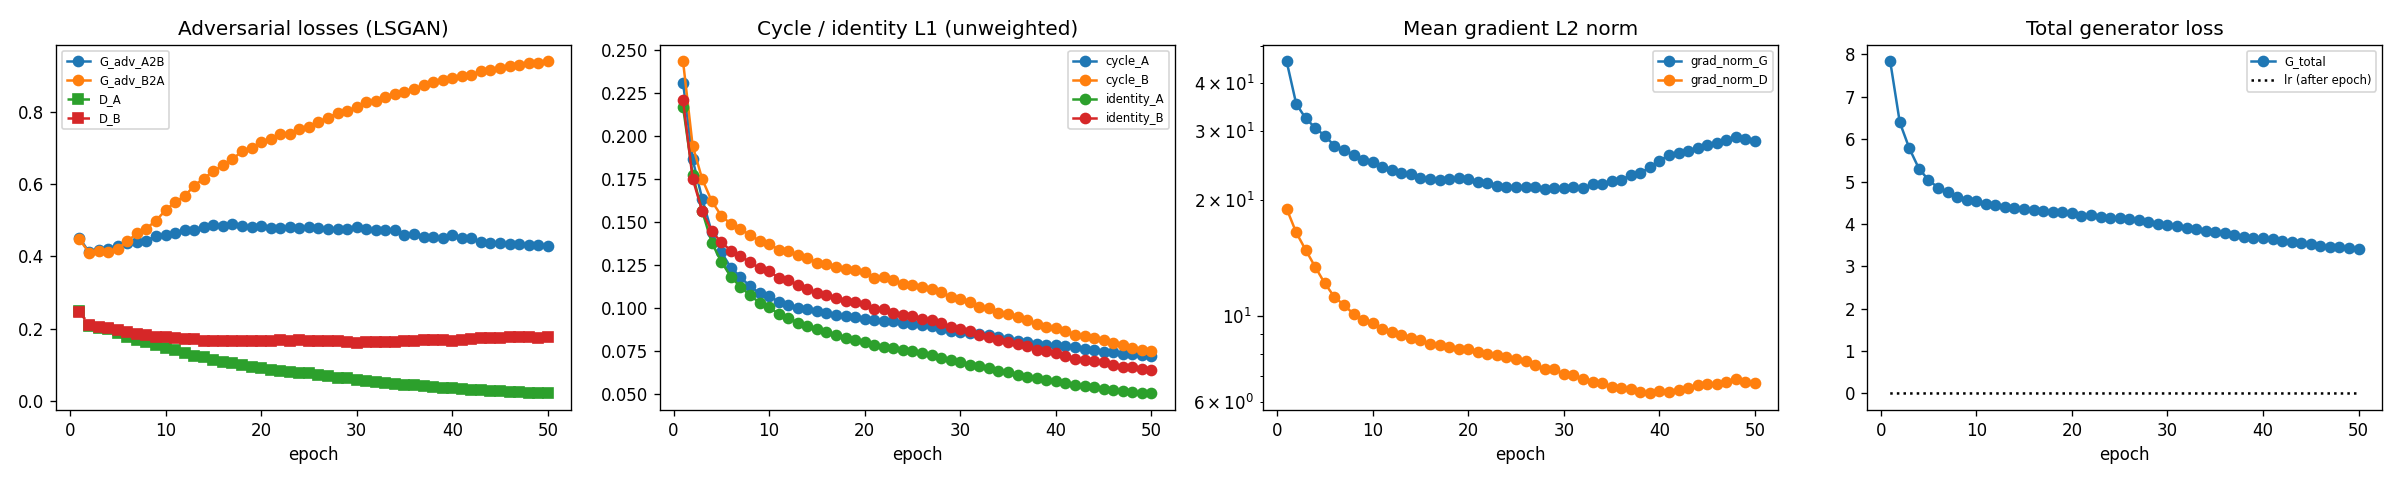

,epoch,G_total,G_adv_A2B,G_adv_B2A,cycle_A,cycle_B,identity_A,identity_B,D_A,D_B,grad_norm_G,grad_norm_D,lr,epoch_time_sec,train_images_per_sec
0,1,7.8364,0.4512,0.4471,0.2312,0.2436,0.2170,0.2209,0.2501,0.2472,45.4905,18.9388,0.0002,197.6749,61.0902
1,2,6.3976,0.4116,0.4103,0.1866,0.1945,0.1776,0.1753,0.2080,0.2113,35.3504,16.4460,0.0002,185.2154,65.1998
2,3,5.7834,0.4178,0.4147,0.1636,0.1751,0.1564,0.1565,0.2011,0.2037,32.3995,14.8124,0.0002,182.1960,66.2803
3,4,5.3076,0.4209,0.4108,0.1441,0.1622,0.1380,0.1447,0.1985,0.2021,30.6479,13.3844,0.0002,184.9141,65.3060
4,5,5.0370,0.4276,0.4217,0.1325,0.1537,0.1269,0.1382,0.1884,0.1964,29.1888,12.1479,0.0002,181.9785,66.3595
5,6,4.8591,0.4361,0.4414,0.1235,0.1489,0.1182,0.1334,0.1772,0.1902,27.5693,11.2060,0.0002,183.0508,65.9707
6,7,4.7518,0.4386,0.4636,0.1180,0.1458,0.1122,0.1301,0.1693,0.1856,26.8630,10.6837,0.0002,183.2456,65.9006
7,8,4.6429,0.4435,0.4769,0.1125,0.1426,0.1074,0.1268,0.1647,0.1838,26.0327,10.1326,0.0002,184.2822,65.5299
8,9,4.5620,0.4573,0.4992,0.1086,0.1389,0.1030,0.1230,0.1555,0.1783,25.3205,9.7976,0.0002,182.0164,66.3457
9,10,4.5396,0.4604,0.5272,0.1069,0.1373,0.1006,0.1213,0.1475,0.1778,25.0510,9.6056,0.0002,180.8707,66.7659


In [3]:
display(Image(out / "loss_curves.png"))
pd.read_csv(out / "train_history.csv").round(4)

## Full metrics (both directions)

In [4]:
pd.set_option("display.max_rows", 100)
pd.read_csv(out / "full_metrics_report.csv")

,direction,metric,value
0,A2B,FID,91.64334533526795
1,A2B,KID_mean,0.027822259872822466
2,A2B,KID_std,0.0009911443523076978
3,A2B,gen_precision,0.7266666666666667
4,A2B,gen_recall,0.344
5,A2B,gen_density,0.7106666666666667
6,A2B,gen_coverage,0.411
7,A2B,cycle_reconstruction_L1,0.037289608269929886
8,A2B,LPIPS_input_vs_translation,0.3767149746417999
9,A2B,LPIPS_input_vs_reconstruction,0.1696338802576065


## Sample translations over training

Rows: real Monet → fake Photo → reconstructed Monet → real Photo → fake Monet → reconstructed Photo (fixed held-out images).

epoch001.png


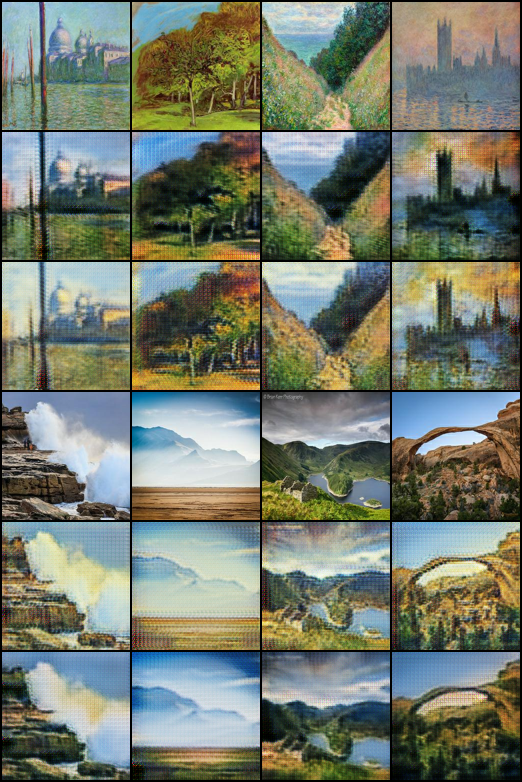

epoch026.png


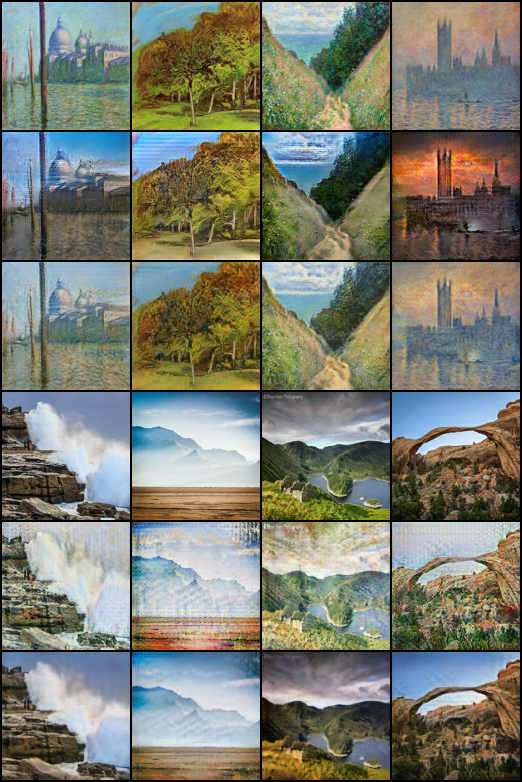

epoch050.png


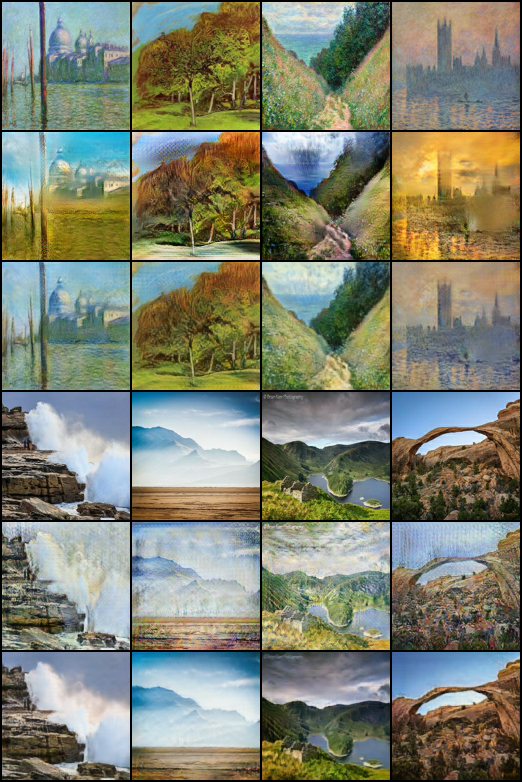

In [5]:
samples = sorted((out / "samples").glob("epoch*.png"))
for p in [samples[0], samples[len(samples) // 2], samples[-1]]:
    print(p.name); display(Image(p))

## Human audit

Blinded sheets are in `human_audit/` (images numbered, direction hidden in the answer key). Two raters fill `ratings_rater1.csv` / `ratings_rater2.csv`, then run:

```bash
python task3_gan/member_nikhil/src/audit_agreement.py task3_gan/member_nikhil/outputs/<run_id>/human_audit
```